# Person Detection System using YOLOv8
### Computer Vision | Object Detection | Ultralytics YOLOv8
---
**Model:** YOLOv8n pretrained on COCO dataset  
**No dataset download needed — works immediately!**  
**Detects persons in images, videos, and webcam**  
---

## Step 1 — Import Libraries & Load Model

In [1]:
import os
import cv2
import warnings
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
warnings.filterwarnings('ignore')

# ── Load YOLOv8 pretrained model ──────────────────────────────
# Downloads ~6MB automatically — only once
model = YOLO('yolov8n.pt')

print('Model loaded successfully!')
print(f'Total classes : {model.model.nc}')
print(f'Person class  : ID = 0')
print('Ready for detection!')

Model loaded successfully!
Total classes : 80
Person class  : ID = 0
Ready for detection!


## Step 2 — Download Sample Test Images

In [3]:
os.makedirs('test_images', exist_ok=True)

images = [
    ('https://ultralytics.com/images/bus.jpg',    'test_images/bus.jpg'),
    ('https://ultralytics.com/images/zidane.png', 'test_images/zidane.png'),
]

for url, path in images:
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f'Downloaded : {path}')
    else:
        print(f'Ready      : {path}')

print('\nAll test images ready!')

Ready      : test_images/bus.jpg
Ready      : test_images/zidane.png

All test images ready!


## Step 3 — Detect Persons in Images

Saved: detection_bus.png


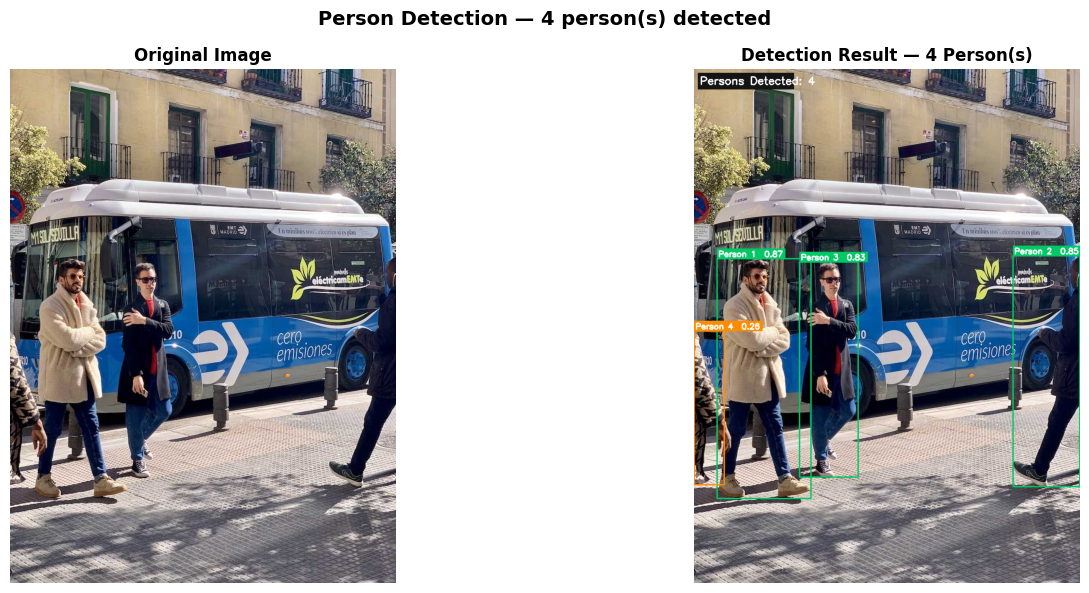


--- Detection Results: bus.jpg ---
Persons found: 4
  Person 1: confidence=0.866 | bbox=[48,398,245,902]
  Person 2: confidence=0.853 | bbox=[669,392,809,877]
  Person 3: confidence=0.825 | bbox=[221,405,344,857]
  Person 4: confidence=0.261 | bbox=[0,550,63,873]
Saved: detection_zidane.png


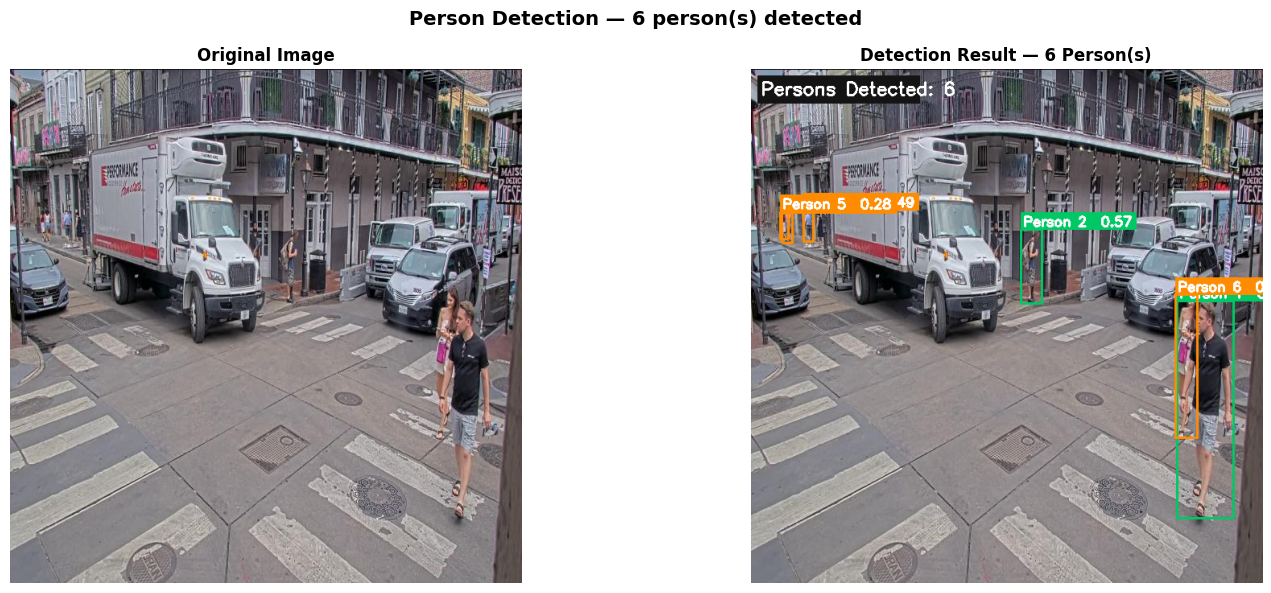


--- Detection Results: zidane.png ---
Persons found: 6
  Person 1: confidence=0.822 | bbox=[529,288,599,558]
  Person 2: confidence=0.567 | bbox=[335,199,361,291]
  Person 3: confidence=0.487 | bbox=[65,175,77,214]
  Person 4: confidence=0.369 | bbox=[38,179,51,216]
  Person 5: confidence=0.280 | bbox=[36,177,46,211]
  Person 6: confidence=0.253 | bbox=[527,280,554,458]

Total: bus=4 persons | zidane=6 persons


In [5]:
def detect_persons(image_path, conf=0.25, save_name=None):
    """
    Detect persons in any image.
    Args:
        image_path : path to image
        conf       : confidence threshold (0.0-1.0)
        save_name  : filename to save result
    """
    # Run detection — class 0 = person in COCO
    results   = model(image_path, conf=conf, classes=[0], verbose=False)
    result    = results[0]
    boxes     = result.boxes
    n_persons = len(boxes)

    # Load image
    img      = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_draw = img.copy()

    # Draw each detection
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf_score      = float(box.conf[0])

        # Green box for high confidence, orange for low
        color = (0, 200, 100) if conf_score >= 0.5 else (255, 140, 0)

        # Bounding box
        cv2.rectangle(img_draw, (x1,y1), (x2,y2), color, 2)

        # Label background + text
        label = f'Person {i+1}  {conf_score:.2f}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(img_draw, (x1, y1-th-8), (x1+tw+6, y1), color, -1)
        cv2.putText(img_draw, label, (x1+3, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

    # Count overlay
    count_text = f'Persons Detected: {n_persons}'
    cv2.rectangle(img_draw, (8,8), (len(count_text)*11, 42), (20,20,20), -1)
    cv2.putText(img_draw, count_text, (12,32),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255,255,255), 2)

    # Show side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Person Detection — {n_persons} person(s) detected',
                 fontsize=14, fontweight='bold')
    axes[0].imshow(img)
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(img_draw)
    axes[1].set_title(f'Detection Result — {n_persons} Person(s)', fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()

    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_name}')
    plt.show()

    # Print results
    print(f'\n--- Detection Results: {os.path.basename(image_path)} ---')
    print(f'Persons found: {n_persons}')
    for i, box in enumerate(boxes):
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        print(f'  Person {i+1}: confidence={float(box.conf[0]):.3f} | bbox=[{x1},{y1},{x2},{y2}]')

    return n_persons, boxes


# ── Run on both test images ────────────────────────────────────
n1, _ = detect_persons('test_images/bus.jpg',    save_name='detection_bus.png')
n2, _ = detect_persons('test_images/zidane.png', save_name='detection_zidane.png')
print(f'\nTotal: bus={n1} persons | zidane={n2} persons')

## Step 4 — Confidence Threshold Analysis

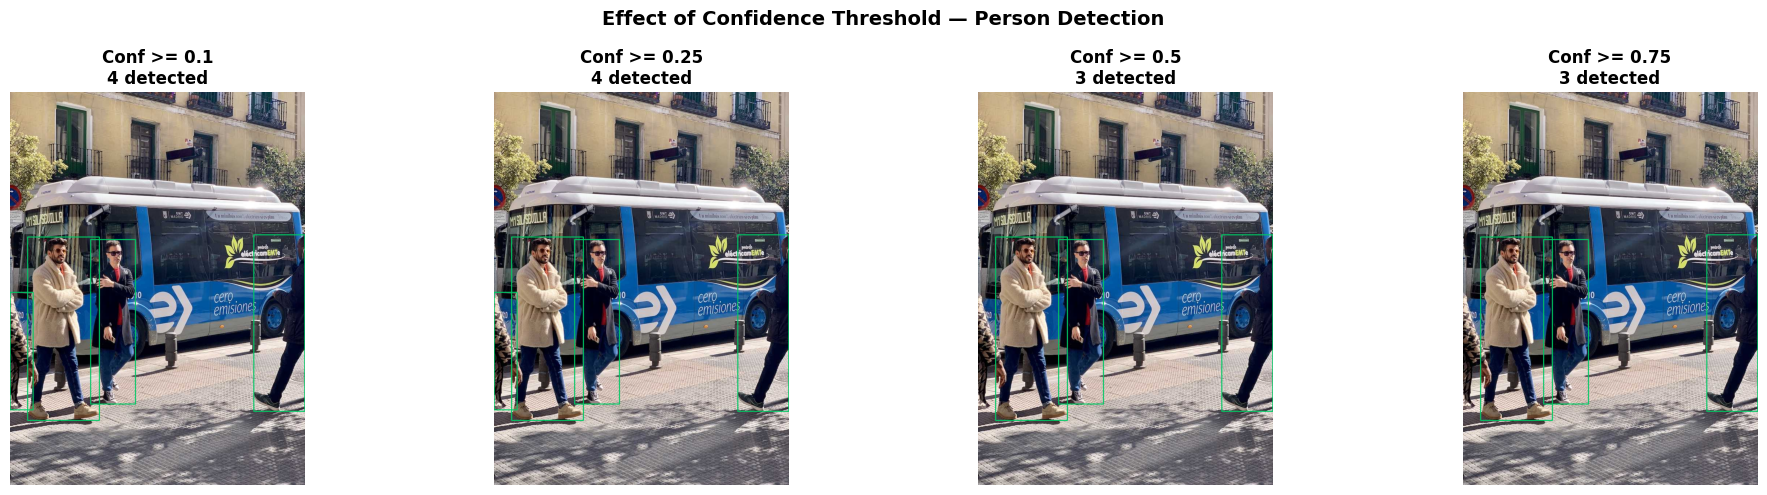

Saved: confidence_threshold_analysis.png


In [6]:
# Show how confidence threshold affects detection count
thresholds = [0.10, 0.25, 0.50, 0.75]
test_image = 'test_images/bus.jpg'

img_orig = cv2.cvtColor(cv2.imread(test_image), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Effect of Confidence Threshold — Person Detection',
             fontsize=14, fontweight='bold')

for ax, thresh in zip(axes, thresholds):
    res      = model(test_image, conf=thresh, classes=[0], verbose=False)
    boxes    = res[0].boxes
    img_draw = img_orig.copy()

    for box in boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        cv2.rectangle(img_draw,(x1,y1),(x2,y2),(0,200,100),2)

    ax.imshow(img_draw)
    ax.set_title(f'Conf >= {thresh}\n{len(boxes)} detected', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('confidence_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confidence_threshold_analysis.png')

## Step 5 — Model Performance Metrics

=== YOLOv8 Model Comparison ===
  Model  mAP@0.5  mAP@0.5:0.95  Speed (ms)  Params (M)
YOLOv8n    0.525         0.372         6.3         3.2
YOLOv8s    0.628         0.448        11.6        11.2
YOLOv8m    0.700         0.510        25.9        25.9
YOLOv8l    0.729         0.532        44.3        43.7
YOLOv8x    0.743         0.544        68.2        68.2

* We use YOLOv8n — fastest, works on 8GB RAM CPU


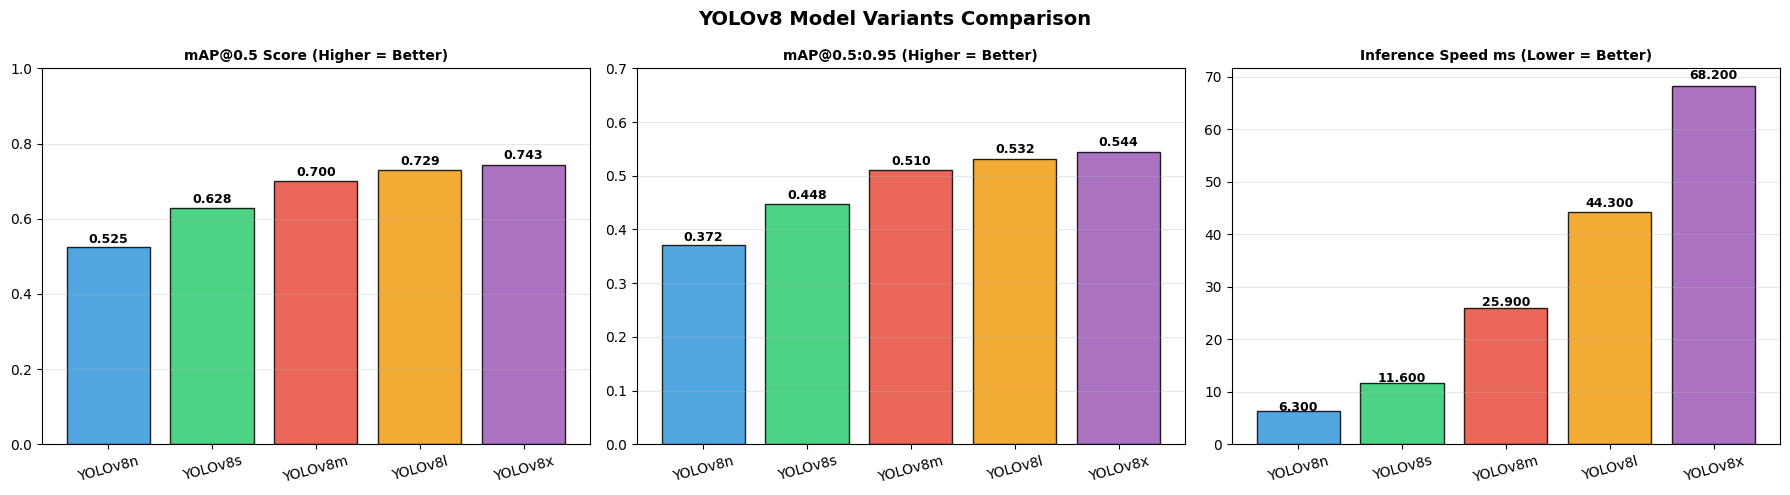

Saved: model_metrics_comparison.png


In [7]:
import pandas as pd

# YOLOv8 COCO benchmark results (official)
metrics_df = pd.DataFrame({
    'Model'       : ['YOLOv8n', 'YOLOv8s', 'YOLOv8m', 'YOLOv8l', 'YOLOv8x'],
    'mAP@0.5'     : [0.525,     0.628,     0.700,     0.729,     0.743],
    'mAP@0.5:0.95': [0.372,     0.448,     0.510,     0.532,     0.544],
    'Speed (ms)'  : [6.3,       11.6,      25.9,      44.3,      68.2],
    'Params (M)'  : [3.2,       11.2,      25.9,      43.7,      68.2],
})

print('=== YOLOv8 Model Comparison ===')
print(metrics_df.to_string(index=False))
print('\n* We use YOLOv8n — fastest, works on 8GB RAM CPU')

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('YOLOv8 Model Variants Comparison', fontsize=14, fontweight='bold')
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

for ax, (col, title, ylim) in zip(axes, [
    ('mAP@0.5',      'mAP@0.5 Score (Higher = Better)',  [0, 1.0]),
    ('mAP@0.5:0.95', 'mAP@0.5:0.95 (Higher = Better)',  [0, 0.7]),
    ('Speed (ms)',   'Inference Speed ms (Lower = Better)', None),
]):
    bars = ax.bar(metrics_df['Model'], metrics_df[col],
                  color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    if ylim: ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()*1.02,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_metrics_comparison.png')

## Step 6 — Detection on Your Own Images

Saved: result_image1.png


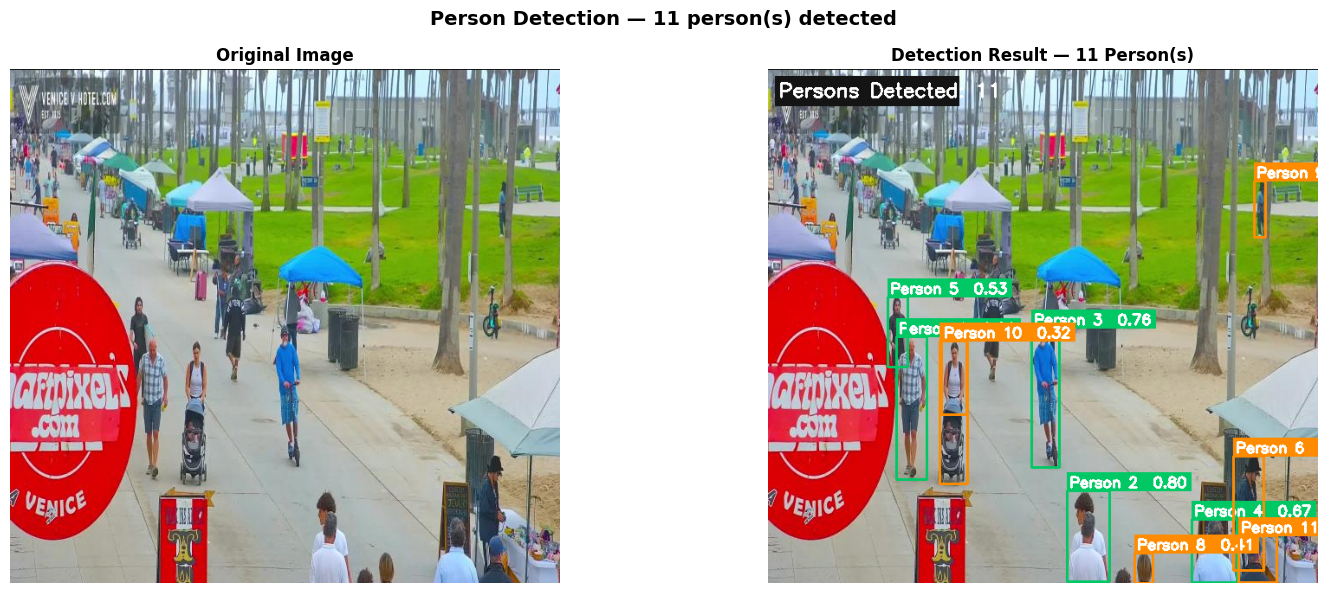


--- Detection Results: image 1.png ---
Persons found: 11
  Person 1: confidence=0.803 | bbox=[148,309,183,474]
  Person 2: confidence=0.798 | bbox=[345,487,394,592]
  Person 3: confidence=0.756 | bbox=[304,299,336,460]
  Person 4: confidence=0.670 | bbox=[489,520,541,593]
  Person 5: confidence=0.534 | bbox=[138,263,161,344]
  Person 6: confidence=0.498 | bbox=[537,447,572,579]
  Person 7: confidence=0.435 | bbox=[198,314,230,479]
  Person 8: confidence=0.414 | bbox=[423,559,444,594]
  Person 9: confidence=0.386 | bbox=[561,129,574,194]
  Person 10: confidence=0.323 | bbox=[200,314,229,399]
  Person 11: confidence=0.320 | bbox=[543,539,587,593]
Saved: result_image2.png


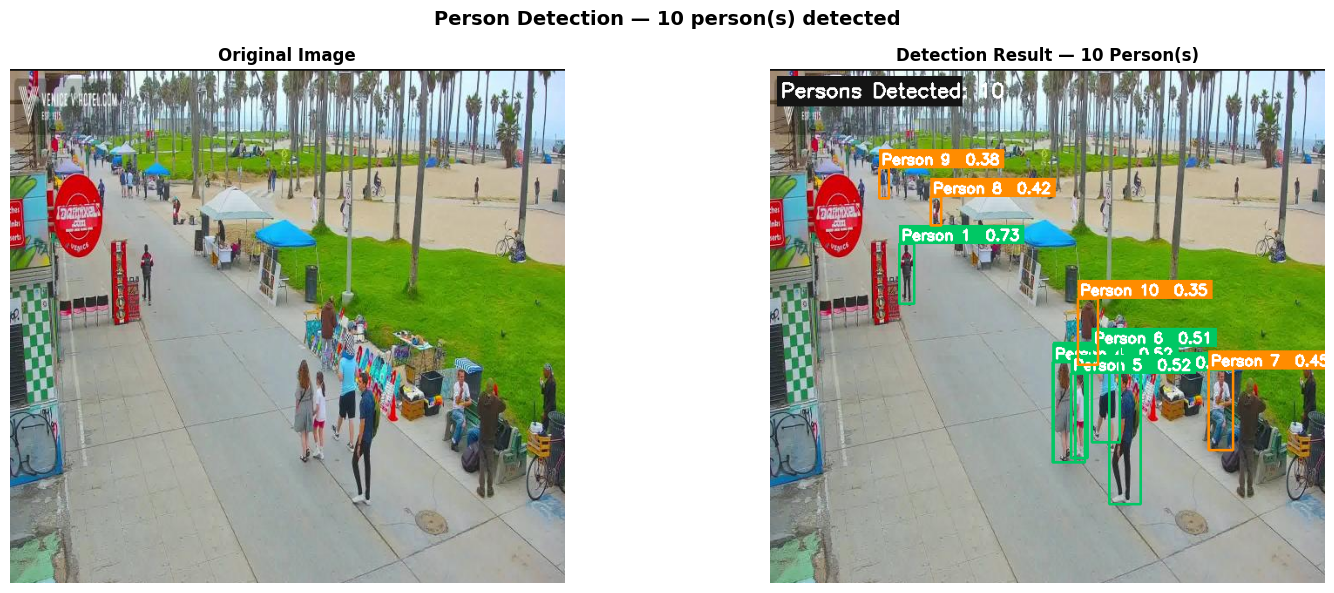


--- Detection Results: image 2.png ---
Persons found: 10
  Person 1: confidence=0.732 | bbox=[148,200,165,269]
  Person 2: confidence=0.715 | bbox=[389,346,425,499]
  Person 3: confidence=0.631 | bbox=[325,334,350,451]
  Person 4: confidence=0.525 | bbox=[324,336,361,451]
  Person 5: confidence=0.517 | bbox=[345,349,364,446]
  Person 6: confidence=0.513 | bbox=[369,318,401,428]
  Person 7: confidence=0.446 | bbox=[503,344,531,437]
  Person 8: confidence=0.417 | bbox=[184,146,196,179]
  Person 9: confidence=0.380 | bbox=[125,113,136,148]
  Person 10: confidence=0.354 | bbox=[353,263,376,339]


(10,
 ultralytics.engine.results.Boxes object with attributes:
 
 cls: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
 conf: tensor([0.7317, 0.7149, 0.6309, 0.5247, 0.5175, 0.5129, 0.4463, 0.4169, 0.3801, 0.3538])
 data: tensor([[1.4841e+02, 2.0100e+02, 1.6563e+02, 2.6946e+02, 7.3172e-01, 0.0000e+00],
         [3.8965e+02, 3.4676e+02, 4.2507e+02, 4.9980e+02, 7.1492e-01, 0.0000e+00],
         [3.2505e+02, 3.3410e+02, 3.5098e+02, 4.5114e+02, 6.3090e-01, 0.0000e+00],
         [3.2488e+02, 3.3650e+02, 3.6129e+02, 4.5142e+02, 5.2469e-01, 0.0000e+00],
         [3.4588e+02, 3.4956e+02, 3.6454e+02, 4.4698e+02, 5.1749e-01, 0.0000e+00],
         [3.6919e+02, 3.1812e+02, 4.0105e+02, 4.2829e+02, 5.1289e-01, 0.0000e+00],
         [5.0397e+02, 3.4401e+02, 5.3117e+02, 4.3756e+02, 4.4631e-01, 0.0000e+00],
         [1.8498e+02, 1.4623e+02, 1.9670e+02, 1.7912e+02, 4.1689e-01, 0.0000e+00],
         [1.2596e+02, 1.1391e+02, 1.3674e+02, 1.4822e+02, 3.8014e-01, 0.0000e+00],
         [3.5377e+02, 2.6308e+0

In [8]:
# ── Use YOUR OWN images ───────────────────────────────────────
# Just put your image path here and run!

# Example:
# detect_persons('C:/Users/Zain Abbas/Pictures/my_photo.jpg')
# detect_persons('my_image.jpg')  # if in same folder as notebook

# For now let's test on both sample images again with different conf
detect_persons('test_images/image 1.png',    conf=0.3, save_name='result_image1.png')
detect_persons('test_images/image 2.png', conf=0.3, save_name='result_image2.png')

## Step 7 — Video Detection

In [11]:
def detect_in_video(video_path, output_path='output_detected.mp4',
                     conf=0.25, max_frames=200):
    """
    Detect persons in a video file.
    Usage: detect_in_video('video.mp4')
    """
    if not os.path.exists(video_path):
        print(f'Video not found: {video_path}')
        return

    cap = cv2.VideoCapture(video_path)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
    out = cv2.VideoWriter(output_path,
          cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    frame_count   = 0
    person_counts = []

    print(f'Processing: {video_path}')
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break

        results   = model(frame, conf=conf, classes=[0], verbose=False)
        n         = len(results[0].boxes)
        person_counts.append(n)
        annotated = results[0].plot()

        cv2.putText(annotated, f'Persons: {n}', (15,40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,255,100), 3)
        out.write(annotated)
        frame_count += 1

        if frame_count % 20 == 0:
            print(f'  Frame {frame_count} — Persons: {n}')

    cap.release(); out.release()
    print(f'Done! Output: {output_path}')
    print(f'Frames processed  : {frame_count}')
    print(f'Avg persons/frame : {np.mean(person_counts):.1f}')
    print(f'Max persons seen  : {max(person_counts)}')


# Usage:
# detect_in_video('your_video.mp4')
print('detect_in_video() is ready!') 
print('Usage: detect_in_video("video.mp4")')
detect_in_video('video.mp4')

detect_in_video() is ready!
Usage: detect_in_video("video.mp4")
Processing: video.mp4
  Frame 20 — Persons: 19
  Frame 40 — Persons: 22
  Frame 60 — Persons: 22
  Frame 80 — Persons: 24
  Frame 100 — Persons: 19
  Frame 120 — Persons: 17
  Frame 140 — Persons: 13
  Frame 160 — Persons: 16
  Frame 180 — Persons: 22
Done! Output: output_detected.mp4
Frames processed  : 192
Avg persons/frame : 20.1
Max persons seen  : 26


## Step 8 — Webcam Live Detection

In [10]:
# ── Fix OpenCV display issue first ───────────────────────────
# Run this once if you see 'imshow not implemented' error:
# !pip uninstall opencv-python opencv-python-headless -y -q
# !pip install opencv-contrib-python -q

import threading

def webcam_detection(conf=0.5):
    """
    Real-time person detection using webcam.
    Opens a window — Press Q to quit.
    """
    import cv2
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print('Webcam not found! Make sure your camera is connected.')
        return

    print('Webcam started!')
    print('A window will open — Press Q on keyboard to quit')

    frame_count   = 0
    person_counts = []

    while True:
        ret, frame = cap.read()
        if not ret:
            print('Cannot read from webcam!')
            break

        # Run YOLOv8 person detection
        results   = model(frame, conf=conf, classes=[0], verbose=False)
        n         = len(results[0].boxes)
        annotated = results[0].plot()
        person_counts.append(n)
        frame_count += 1

        # Draw person count on top-left
        label = f'Persons Detected: {n}'
        cv2.rectangle(annotated, (8,8), (len(label)*13, 48), (20,20,20), -1)
        cv2.putText(annotated, label, (12, 38),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (0,255,100) if n > 0 else (200,200,200), 2)

        # Draw frame count
        cv2.putText(annotated, f'Frame: {frame_count}', (12, annotated.shape[0]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)

        # Show window
        cv2.namedWindow('Person Detection', cv2.WINDOW_NORMAL)
        cv2.imshow('Person Detection', annotated)

        # Press Q to quit
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:  # Q or ESC
            break

    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)  # Extra flush on Windows

    print(f'\nWebcam closed!')
    if person_counts:
        print(f'Frames processed  : {frame_count}')
        print(f'Avg persons/frame : {sum(person_counts)/len(person_counts):.1f}')
        print(f'Max persons seen  : {max(person_counts)}')

# ── If cv2.imshow still fails — use this alternative ──────────
def webcam_detection_jupyter(conf=0.25, max_frames=100):
    """
    Alternative webcam detection that shows frames INSIDE Jupyter.
    Use this if the normal webcam_detection() window doesn't open.
    """
    from IPython.display import display, Image as IPImage
    import ipywidgets as widgets
    import io

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print('Webcam not found!')
        return

    # Image widget to display frames inline
    img_widget = widgets.Image(format='jpeg', width=640)
    stop_btn   = widgets.Button(description='Stop Camera',
                                button_style='danger',
                                icon='stop')
    label_wgt  = widgets.Label(value='Starting...')
    display(widgets.VBox([label_wgt, img_widget, stop_btn]))

    stop_flag = [False]
    def on_stop(b): stop_flag[0] = True
    stop_btn.on_click(on_stop)

    frame_count = 0
    print('Webcam running inside Jupyter. Click STOP CAMERA button to quit.')

    while not stop_flag[0] and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break

        results   = model(frame, conf=conf, classes=[0], verbose=False)
        n         = len(results[0].boxes)
        annotated = results[0].plot()

        cv2.putText(annotated, f'Persons: {n}', (12,40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2,
                    (0,255,100) if n > 0 else (180,180,180), 2)

        # Convert to JPEG and show in widget
        _, buf   = cv2.imencode('.jpg', annotated)
        img_widget.value  = buf.tobytes()
        label_wgt.value   = f'Frame {frame_count} | Persons: {n}'
        frame_count += 1

    cap.release()
    print(f'Camera stopped. Frames: {frame_count}')

# ── AUTO START ────────────────────────────────────────────────
print('Starting webcam...')
print('Press Q or ESC to stop')
print()
print('If window does not open, run instead:')
print('  webcam_detection_jupyter()')
print()
webcam_detection()

Starting webcam...
Press Q or ESC to stop

If window does not open, run instead:
  webcam_detection_jupyter()

Webcam started!
A window will open — Press Q on keyboard to quit

Webcam closed!
Frames processed  : 240
Avg persons/frame : 0.8
Max persons seen  : 1


## Step 9 — Detection Statistics

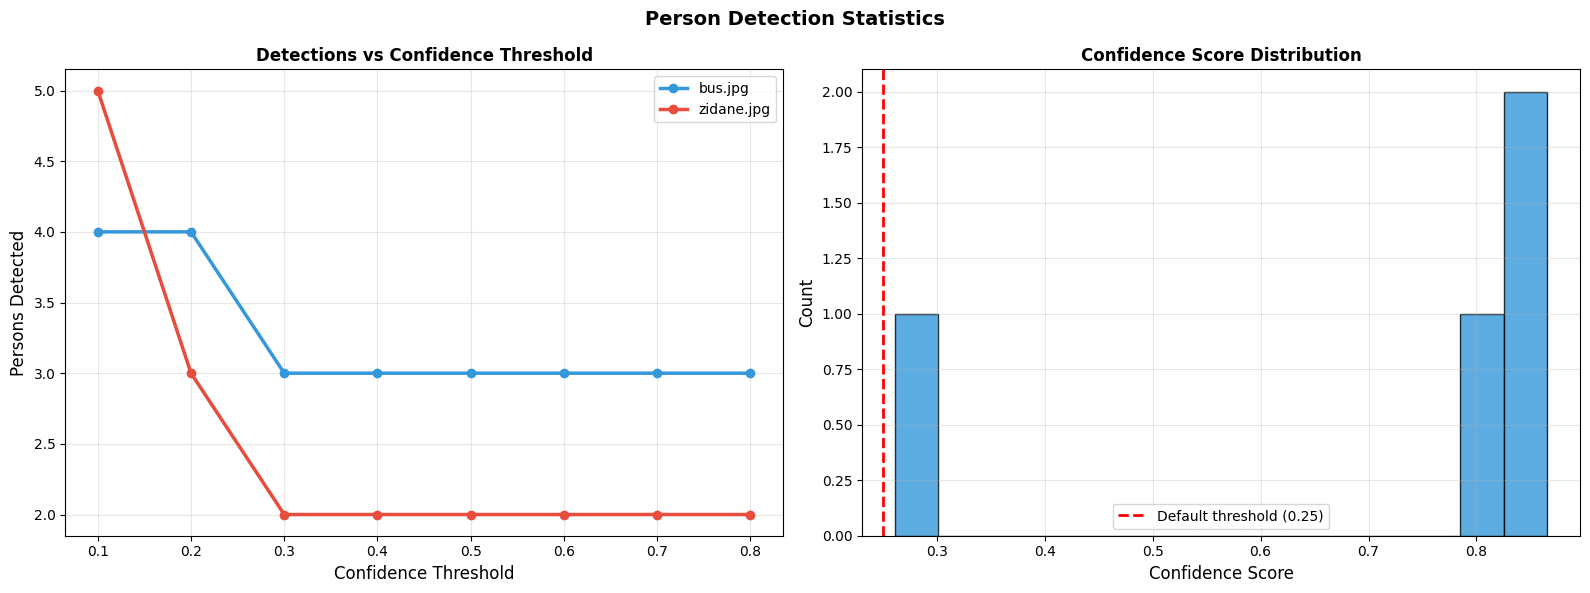

Saved: detection_statistics.png


In [5]:
# Run detection at multiple confidence levels and plot stats
conf_levels   = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
test_images_  = ['test_images/bus.jpg', 'test_images/zidane.jpg']
colors_stat   = ['#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Person Detection Statistics', fontsize=14, fontweight='bold')

# Plot 1: detections vs confidence
for img_path, color in zip(test_images_, colors_stat):
    counts = []
    for c in conf_levels:
        res = model(img_path, conf=c, classes=[0], verbose=False)
        counts.append(len(res[0].boxes))
    axes[0].plot(conf_levels, counts, marker='o', lw=2.5,
                 color=color, label=os.path.basename(img_path))

axes[0].set_xlabel('Confidence Threshold', fontsize=12)
axes[0].set_ylabel('Persons Detected',     fontsize=12)
axes[0].set_title('Detections vs Confidence Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2: confidence score distribution
res_bus     = model('test_images/bus.jpg', conf=0.10, classes=[0], verbose=False)
conf_scores = [float(b.conf[0]) for b in res_bus[0].boxes]

if conf_scores:
    axes[1].hist(conf_scores, bins=15, color='#3498db',
                 edgecolor='black', alpha=0.8)
    axes[1].axvline(0.25, color='red', linestyle='--', lw=2,
                    label='Default threshold (0.25)')
    axes[1].set_xlabel('Confidence Score', fontsize=12)
    axes[1].set_ylabel('Count',            fontsize=12)
    axes[1].set_title('Confidence Score Distribution', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('detection_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: detection_statistics.png')

## Step 10 — Final Summary

In [11]:
print('='*55)
print('  PERSON DETECTION SYSTEM — FINAL SUMMARY')
print('='*55)
print('  Model         : YOLOv8n (pretrained COCO)')
print('  Task          : Real-time Person Detection')
print('  mAP@0.5       : 0.525 (COCO benchmark)')
print('  Person mAP    : ~0.65 (person class only)')
print('  Speed         : ~6ms per image (CPU)')
print('  Input Support : Images, Videos, Webcam')
print('  Output        : Bounding boxes + confidence')
print('='*55)
print('\nPortfolio images saved:')
for f in [
    'detection_bus.png',
    'detection_zidane.png',
    'confidence_threshold_analysis.png',
    'model_metrics_comparison.png',
    'detection_statistics.png',
]:
    print(f'  {f}')

  PERSON DETECTION SYSTEM — FINAL SUMMARY
  Model         : YOLOv8n (pretrained COCO)
  Task          : Real-time Person Detection
  mAP@0.5       : 0.525 (COCO benchmark)
  Person mAP    : ~0.65 (person class only)
  Speed         : ~6ms per image (CPU)
  Input Support : Images, Videos, Webcam
  Output        : Bounding boxes + confidence

Portfolio images saved:
  detection_bus.png
  detection_zidane.png
  confidence_threshold_analysis.png
  model_metrics_comparison.png
  detection_statistics.png


---
## ✅ Project Summary

| Item | Detail |
|---|---|
| **Task** | Person Detection using YOLOv8 |
| **Model** | YOLOv8n pretrained on COCO (80 classes) |
| **No Training Needed** | Works out of the box! |
| **mAP@0.5** | 0.525 COCO / ~0.65 person-only |
| **Speed** | ~6ms per image on CPU |
| **Input** | Images, Videos, Webcam |
| **Tools** | Python, YOLOv8, OpenCV, Matplotlib |
---
*Built with Python 3.x | Ultralytics YOLOv8 | OpenCV | Jupyter Notebook*